In [186]:
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path
import seaborn as sns
import numpy as np

Data_path= Path("..")/"data"
raw_path = Data_path/"raw"/"StudentsPerformance.csv"
df = pd.read_csv(raw_path)
#https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html 
# --> using this to help me out when stuck 


EDA

In [187]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [188]:
df.shape

(1000, 8)

In [189]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [190]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [191]:
a = df.describe().to_string()
print(a)

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [192]:
missing_count = df.isna().sum()
print("Missing rows:\n", missing_count)

Missing rows:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [193]:
duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [194]:
df["overall avg"]= (df["math score"]+ df["reading score"] + df["writing score"])/3
df["overall avg"] = df["overall avg"].round(2)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


In [195]:
print("Score Mins & Max")
print("Math min: ", df["math score"].min())
print("Math max: ", df["math score"].max())

print("Reading min: ", df["reading score"].min())
print("Reading max: ", df["reading score"].max())

print("Writing min: ", df["writing score"].min())
print("Writing max: ", df["writing score"].max())

Score Mins & Max
Math min:  0
Math max:  100
Reading min:  17
Reading max:  100
Writing min:  10
Writing max:  100


In [196]:
print("Unique Values for Categorical Data")
print("Gender : ", df["gender"].unique())
print("Race/ethinicity : ", df["race/ethnicity"].unique())
print("lunch : ", df["lunch"].unique())
print("Test Perp : ", df["test preparation course"].unique())



Unique Values for Categorical Data
Gender :  <StringArray>
['female', 'male']
Length: 2, dtype: str
Race/ethinicity :  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
lunch :  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Test Perp :  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [197]:
clean_path = clean_path = Data_path/"clean"/"StudentsPerformanceCleaned.csv"
df.to_csv(clean_path,index = False)

Visulizations

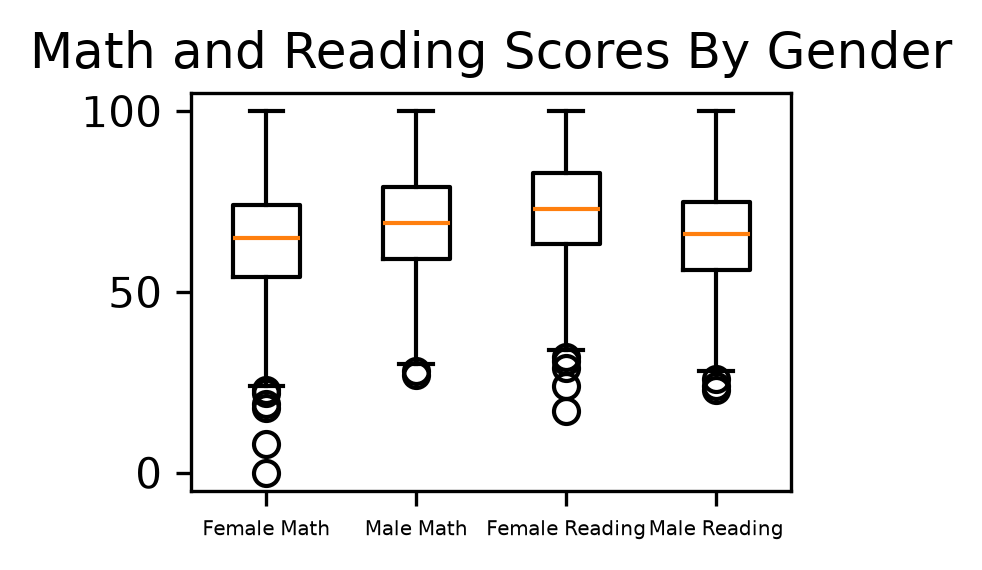

In [198]:
DPI=300
FIG_SIZE = (800/DPI, 600/DPI)

fig1,ax1 = plt.subplots(figsize=FIG_SIZE,dpi=DPI)
group = [
    df.loc[df["gender"] == "female", "math score"],
    df.loc[df["gender"] == "male", "math score"],
    df.loc[df["gender"] == "female", "reading score"],
    df.loc[df["gender"] == "male", "reading score"],
]

ax1.boxplot(group,tick_labels=["Female Math", "Male Math", "Female Reading", "Male Reading"])
ax1.tick_params(axis="x",labelsize=4.8)
ax1.set_title("Math and Reading Scores By Gender")
plt.tight_layout()
plt.show()

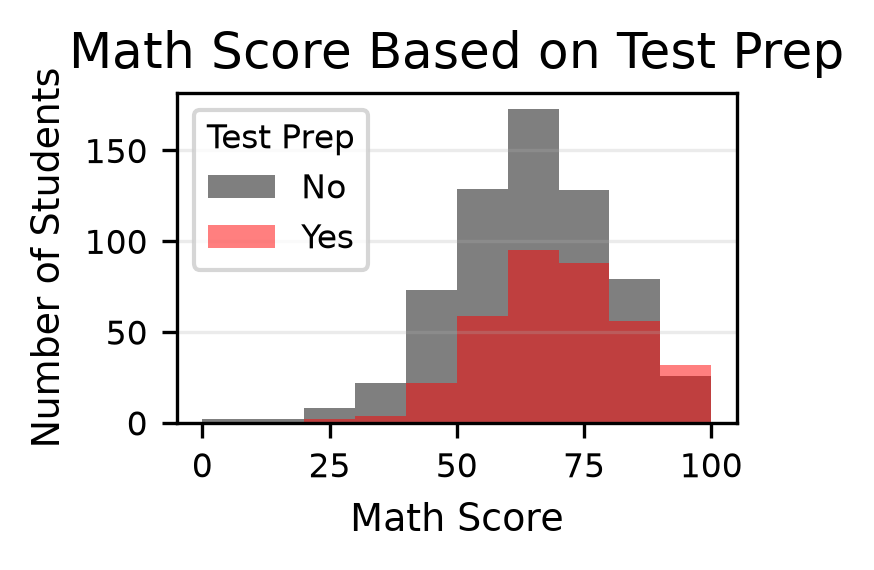

In [199]:
no_prep =df.loc[df["test preparation course"]=="none","math score"]
prep =df.loc[df["test preparation course"]=="completed","math score"]

fig2,ax2= plt.subplots(figsize=FIG_SIZE, dpi=DPI)
ax2.hist(no_prep,bins=range(0,105,10),alpha = .5,color="black", label="No")
ax2.hist(prep,bins=range(0,105,10),alpha = .5,color="red", label="Yes")
ax2.tick_params(axis="x", labelsize=8)
ax2.tick_params(axis="y", labelsize=8)
ax2.set_title("Math Score Based on Test Prep", fontsize= 12)
ax2.set_xlabel("Math Score", fontsize= 9)
ax2.set_ylabel("Number of Students", fontsize= 9)
ax2.legend(title ="Test Prep",title_fontsize = 8, fontsize=8, loc="upper left")
ax2.grid(axis="y",alpha =.25)
plt.tight_layout()
plt.show()

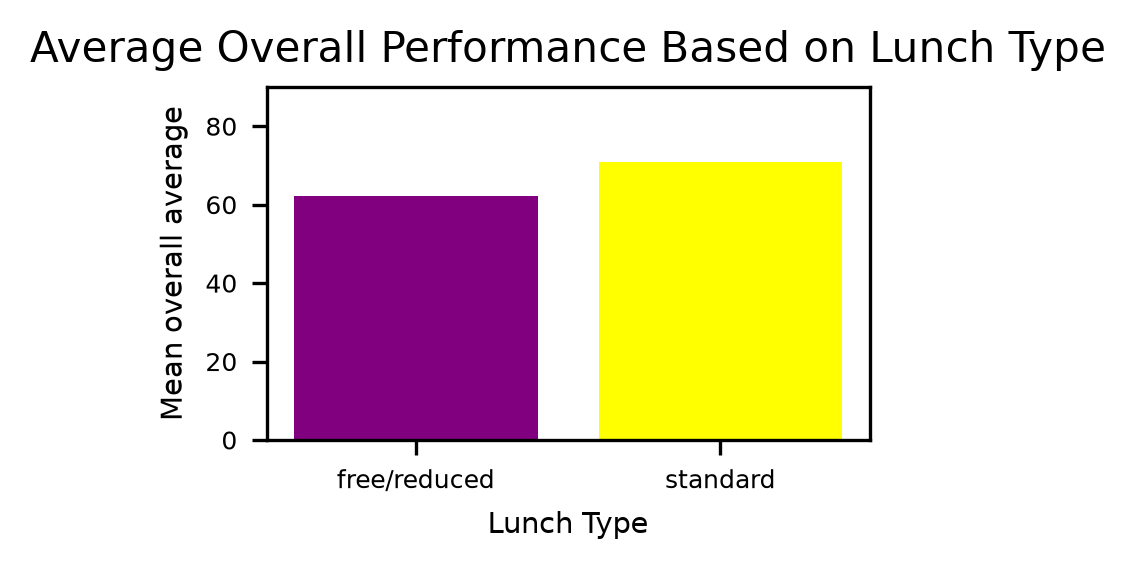

In [200]:
means= df.groupby("lunch")["overall avg"].mean()

fig3,ax3= plt.subplots(figsize=FIG_SIZE, dpi=DPI)
bars=ax3.bar(means.index,means.values,color=["purple","yellow"])
ax3.set_title("Average Overall Performance Based on Lunch Type",fontsize=10)
ax3.set_xlabel("Lunch Type",fontsize = 7)
ax3.set_ylabel("Mean overall average", fontsize = 7)
ax3.set_ylim(0,90)
ax3.tick_params(axis="both",labelsize=6)
plt.tight_layout()
plt.show()

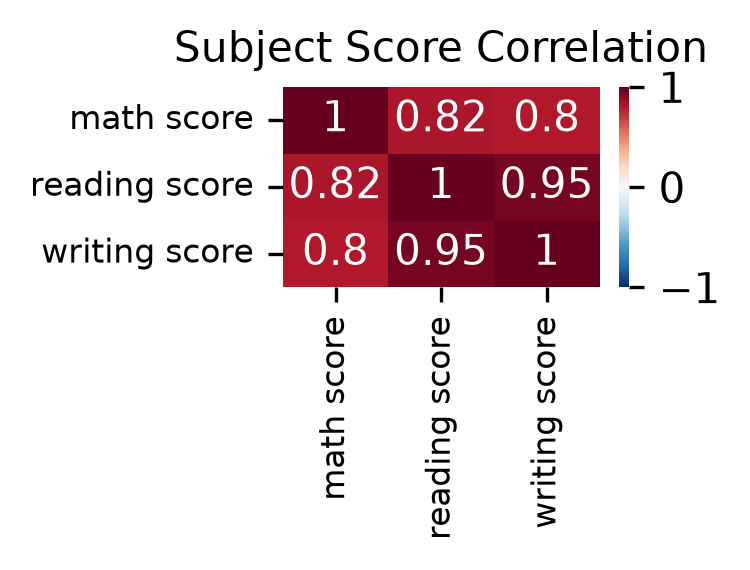

In [201]:
#https://seaborn.pydata.org/generated/seaborn.heatmap.html 
#https://www.geeksforgeeks.org/python/seaborn-heatmap-a-comprehensive-guide/
corre = df[["math score","reading score", "writing score"]].corr()

fig4,ax4=plt.subplots(figsize=FIG_SIZE,dpi=DPI)
sns.heatmap(corre,vmin=-1, vmax=1,cmap="RdBu_r",annot=True,)
ax4.set_title("Subject Score Correlation", fontsize=10)
ax4.tick_params(axis="both", labelsize=8)
plt.tight_layout()
plt.show()

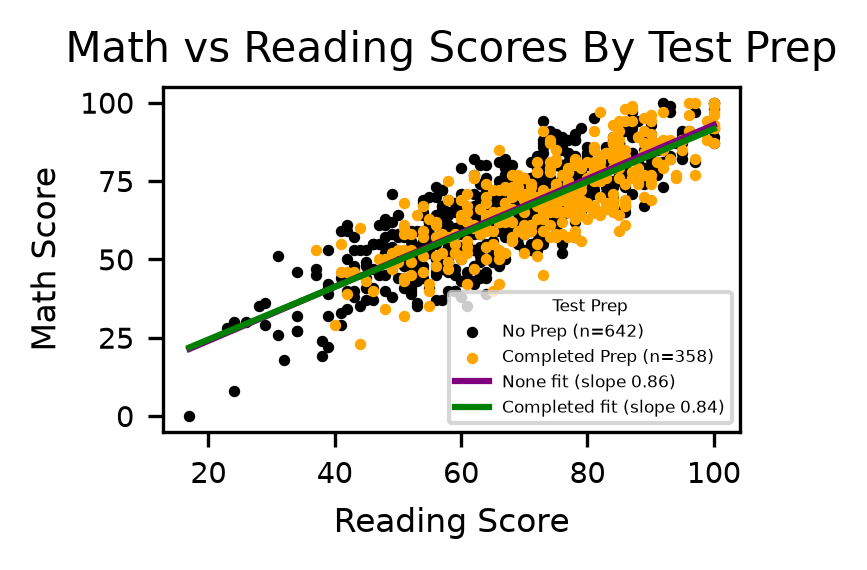

In [202]:
#https://matplotlib.org/stable/gallery/shapes_and_collections/scatter.html 
#https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html
none = yes_prep = df[df["test preparation course"]=="none"]
completed = df[df["test preparation course"]=="completed"]

fig5,ax5= plt.subplots(figsize=FIG_SIZE,dpi=DPI)
ax5.scatter(none["reading score"],none["math score"],color="black", label=f"No Prep (n={len(none)})", s=3)
ax5.scatter(completed["reading score"],completed["math score"],color="orange", label=f"Completed Prep (n={len(completed)})", s=3)
ax5.set_title("Math vs Reading Scores By Test Prep",fontsize=10)
ax5.set_ylabel("Math Score", fontsize=8)
ax5.set_xlabel("Reading Score", fontsize=8)
ax5.tick_params(axis="both", labelsize=7)
#https://www.geeksforgeeks.org/data-analysis/numpys-polyfit-function-a-comprehensive-guide/
#https://numpy.org/doc/2.5/reference/generated/numpy.polyfit.html

slope_none, intercept_none = np.polyfit(none["reading score"],none["math score"], 1)
slope_complete, intrcept_complete = np.polyfit(completed["reading score"], completed["math score"],1)
line = np.array([df["reading score"].min(), df["reading score"].max()])
y_none = slope_none * line + intercept_none
y_complete = slope_complete * line + intrcept_complete

ax5.plot(line,y_none, color="purple", linewidth = 1.5,label=f"None fit (slope {slope_none:.2f})")
ax5.plot(line,y_complete, color="green", linewidth = 1.5,label=f"Completed fit (slope {slope_complete:.2f})")
ax5.legend(fontsize=4, title="Test Prep", title_fontsize=4, loc="lower right")

plt.tight_layout()
plt.show()